In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# data frame

df = pd.read_csv('used_cars.csv')
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (4009, 12)

Missing values:
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
# Data cleaning and preprocessing

# Clean price: remove $ and commas, convert to float 
df['price'] = df['price'].str.replace('$', '', regex=False)\
                         .str.replace(',', '', regex=False).astype(float)

# Clean mileage: remove 'mi.' and commas, convert to float 
df['milage'] = df['milage'].str.replace(' mi.', '', regex=False)\
                            .str.replace(',', '', regex=False).astype(float)

# Feature engineering: extract horsepower from engine string
df['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)

# Feature engineering: car age from model year
df['car_age'] = 2025 - df['model_year']

# Binary mapping
df['accident'] = df['accident'].map(
    {'None reported': 0, 'At least 1 accident or damage reported': 1}
)
df['clean_title'] = df['clean_title'].map({'Yes': 1})
df['clean_title'] = df['clean_title'].fillna(0)

# Fill missing fuel_type with mode
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])

# Drop rows where accident is still missing
df = df.dropna(subset=['accident', 'horsepower'])

print(f"Shape after cleaning: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df[['price', 'milage', 'horsepower', 'car_age', 'accident', 'clean_title']].head()

Shape after cleaning: (3118, 14)

Missing values:
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
horsepower      0
car_age         0
dtype: int64


,price,milage,horsepower,car_age,accident,clean_title
0,10300.0,51000.0,300.0,12,1.0,1.0
3,15500.0,88900.0,354.0,10,0.0,1.0
6,31000.0,84000.0,292.0,8,0.0,1.0
7,7300.0,242000.0,282.0,24,0.0,1.0
8,41927.0,23436.0,311.0,4,0.0,1.0


In [4]:
# One-hot encode categorical features
cat_cols = ['brand', 'fuel_type', 'transmission', 'ext_col', 'int_col']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Drop columns we no longer need 
df_encoded = df_encoded.drop(columns=['model', 'engine', 'model_year'])

print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()

Shape after encoding: (3118, 109)


,milage,accident,clean_title,price,horsepower,car_age,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,...,int_col_Brown,int_col_Gold,int_col_Gray,int_col_Green,int_col_Orange,int_col_Red,int_col_Silver,int_col_White,int_col_Yellow,int_col_–
0,51000.0,1.0,1.0,10300.0,300.0,12,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,88900.0,0.0,1.0,15500.0,354.0,10,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,84000.0,0.0,1.0,31000.0,292.0,8,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
7,242000.0,0.0,1.0,7300.0,282.0,24,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False
8,23436.0,0.0,1.0,41927.0,311.0,4,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Define features and target
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# Train/test split BEFORE scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numerical features only 
num_cols = ['milage', 'horsepower', 'car_age']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (2494, 108)
Testing set: (624, 108)


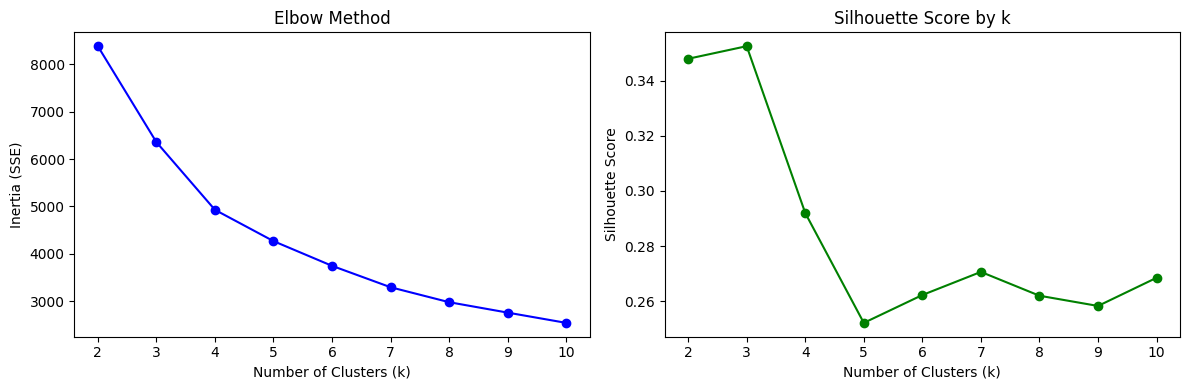


Silhouette scores:
  k=2: 0.3479
  k=3: 0.3525
  k=4: 0.2920
  k=5: 0.2521
  k=6: 0.2622
  k=7: 0.2706
  k=8: 0.2620
  k=9: 0.2583
  k=10: 0.2685


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Cluster on key numerical features only
cluster_features = ['price', 'milage', 'horsepower', 'car_age']
X_cluster = df_encoded[cluster_features].copy()

# Scale for clustering
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

inertias = []
sil_scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, km.labels_))
    
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].set_title('Elbow Method')

axes[1].plot(K, sil_scores, 'go-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K, sil_scores):
    print(f"  k={k}: {s:.4f}")

In [7]:
# Fit final K-Means with k=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_encoded['cluster'] = km_final.fit_predict(X_cluster_scaled)

# Analyze cluster characteristics
cluster_summary = df_encoded.groupby('cluster')[cluster_features].mean()
print("Cluster Summary (mean values):")
print(cluster_summary)

# Label clusters by average price
price_order = cluster_summary['price'].rank()
label_map = {price_order.idxmin(): 'Budget', 
             price_order.index[price_order == 2.0][0]: 'Mid-Range',
             price_order.idxmax(): 'Premium'}
df_encoded['segment'] = df_encoded['cluster'].map(label_map)
print("\nSegment counts:")
print(df_encoded['segment'].value_counts())

# Inspect the outlier cluster
print("\nOutlier Sample:")
print(df_encoded[df_encoded['segment'] == 'Premium'][['milage', 'horsepower', 'car_age']].head())
print(df[df_encoded['segment'] == 'Premium'][['brand', 'model', 'price', 'milage']].head())

# Remove price outliers
Q1 = df_encoded['price'].quantile(0.01)
Q99 = df_encoded['price'].quantile(0.99)
df_encoded = df_encoded[(df_encoded['price'] >= Q1) & (df_encoded['price'] <= Q99)]

print(f"Shape after removing price outliers: {df_encoded.shape}")
print(f"Price range: ${df_encoded['price'].min():,.0f} - ${df_encoded['price'].max():,.0f}")

Cluster Summary (mean values):
                price         milage  horsepower    car_age
cluster                                                    
0        5.347011e+04   38625.802594  378.407783   6.650874
1        1.563995e+04  115817.057334  269.012658  15.227848
2        2.276542e+06   18200.000000  499.500000  20.000000

Segment counts:
segment
Mid-Range    1773
Budget       1343
Premium         2
Name: count, dtype: int64

Outlier Sample:
       milage  horsepower  car_age
693   32000.0       394.0       20
3046   4400.0       605.0       20
         brand              model      price   milage
693   Maserati  Quattroporte Base  2954083.0  32000.0
3046   Porsche    Carrera GT Base  1599000.0   4400.0
Shape after removing price outliers: (3054, 111)
Price range: $3,999 - $179,900


In [8]:
# Rerun clustering on cleaned data 
cluster_features = ['price', 'milage', 'horsepower', 'car_age']
X_cluster = df_encoded[cluster_features].copy()

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_encoded['cluster'] = km_final.fit_predict(X_cluster_scaled)

# Label clusters by average price 
cluster_summary = df_encoded.groupby('cluster')[cluster_features].mean()
price_order = cluster_summary['price'].rank()
label_map = {price_order.idxmin(): 'Budget',
             price_order.index[price_order == 2.0][0]: 'Mid-Range',
             price_order.idxmax(): 'Premium'}
df_encoded['segment'] = df_encoded['cluster'].map(label_map)

print("Cluster Summary (mean values):")
print(cluster_summary.round(1))
print("\nSegment counts:")
print(df_encoded['segment'].value_counts())

Cluster Summary (mean values):
           price    milage  horsepower  car_age
cluster                                        
0        75149.5   27276.1       480.4      6.0
1        14304.9  122765.7       272.8     16.2
2        31818.8   52801.3       300.1      7.7

Segment counts:
segment
Mid-Range    1330
Budget       1057
Premium       667
Name: count, dtype: int64


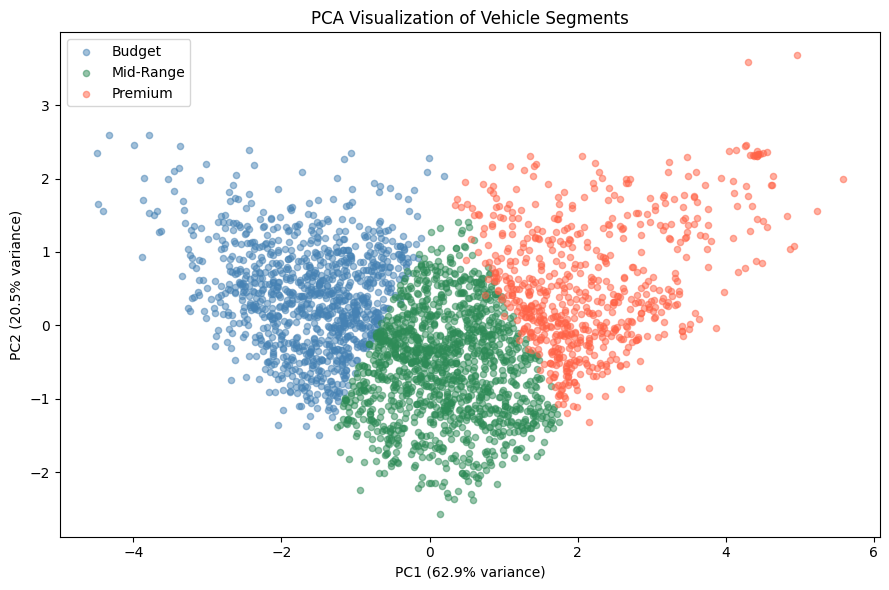

Total variance explained: 83.4%


In [9]:
from sklearn.decomposition import PCA

# PCA for visualization 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(9, 6))
colors = {'Budget': 'steelblue', 'Mid-Range': 'seagreen', 'Premium': 'tomato'}
for segment, color in colors.items():
    mask = df_encoded['segment'] == segment
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=color, label=segment, alpha=0.5, s=20)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA Visualization of Vehicle Segments')
plt.legend()
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Rebuild train/test split on cleaned data
X = df_encoded.drop(columns=['price', 'cluster', 'segment'])
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = ['milage', 'horsepower', 'car_age']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Global baseline: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)
print("Global Linear Regression (Baseline):")
print(f"  RMSE: ${lr_rmse:,.0f}")
print(f"  R²:   {lr_r2:.4f}")

Global Linear Regression (Baseline):
  RMSE: $16,124
  R²:   0.6954


In [11]:
# Global Random Forest 
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)
print("Global Random Forest:")
print(f"  RMSE: ${rf_rmse:,.0f}")
print(f"  R²:   {rf_r2:.4f}")

# Global XGBoost 
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)
print("\nGlobal XGBoost:")
print(f"  RMSE: ${xgb_rmse:,.0f}")
print(f"  R²:   {xgb_r2:.4f}")

Global Random Forest:
  RMSE: $12,591
  R²:   0.8142

Global XGBoost:
  RMSE: $10,830
  R²:   0.8626


In [12]:
# Segment-specific models
segments = ['Budget', 'Mid-Range', 'Premium']
seg_results = {}

for seg in segments:
    # Filter data for this segment
    mask = df_encoded['segment'] == seg
    X_seg = df_encoded[mask].drop(columns=['price', 'cluster', 'segment'])
    y_seg = df_encoded[mask]['price']
    
    # Train/test split per segment
    X_str, X_ste, y_str, y_ste = train_test_split(
        X_seg, y_seg, test_size=0.2, random_state=42
    )
    
    # Scale
    seg_scaler = StandardScaler()
    X_str[num_cols] = seg_scaler.fit_transform(X_str[num_cols])
    X_ste[num_cols] = seg_scaler.transform(X_ste[num_cols])
    
    # XGBoost per segment
    xgb_seg = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb_seg.fit(X_str, y_str)
    preds = xgb_seg.predict(X_ste)
    
    rmse = np.sqrt(mean_squared_error(y_ste, preds))
    r2 = r2_score(y_ste, preds)
    seg_results[seg] = {'RMSE': rmse, 'R2': r2, 'model': xgb_seg,
                        'X_test': X_ste, 'y_test': y_ste}
    print(f"{seg}: RMSE=${rmse:,.0f}, R²={r2:.4f}")

Budget: RMSE=$5,010, R²=0.5316
Mid-Range: RMSE=$6,840, R²=0.6505
Premium: RMSE=$17,819, R²=0.5971


In [13]:
# Accident penalty analysis per segment 
print("Average price by accident history per segment:")

accident_results = {}
for seg in segments:
    mask = df_encoded['segment'] == seg
    seg_data = df_encoded[mask]
    
    no_accident = seg_data[seg_data['accident'] == 0]['price'].mean()
    has_accident = seg_data[seg_data['accident'] == 1]['price'].mean()
    penalty = no_accident - has_accident
    penalty_pct = (penalty / no_accident) * 100
    
    accident_results[seg] = {
        'No Accident': no_accident,
        'Has Accident': has_accident,
        'Penalty $': penalty,
        'Penalty %': penalty_pct
    }
    print(f"\n{seg}:")
    print(f"  No accident:  ${no_accident:,.0f}")
    print(f"  Has accident: ${has_accident:,.0f}")
    print(f"  Penalty:      ${penalty:,.0f} ({penalty_pct:.1f}%)")

Average price by accident history per segment:

Budget:
  No accident:  $14,754
  Has accident: $13,620
  Penalty:      $1,134 (7.7%)

Mid-Range:
  No accident:  $33,225
  Has accident: $27,956
  Penalty:      $5,270 (15.9%)

Premium:
  No accident:  $76,566
  Has accident: $66,405
  Penalty:      $10,161 (13.3%)


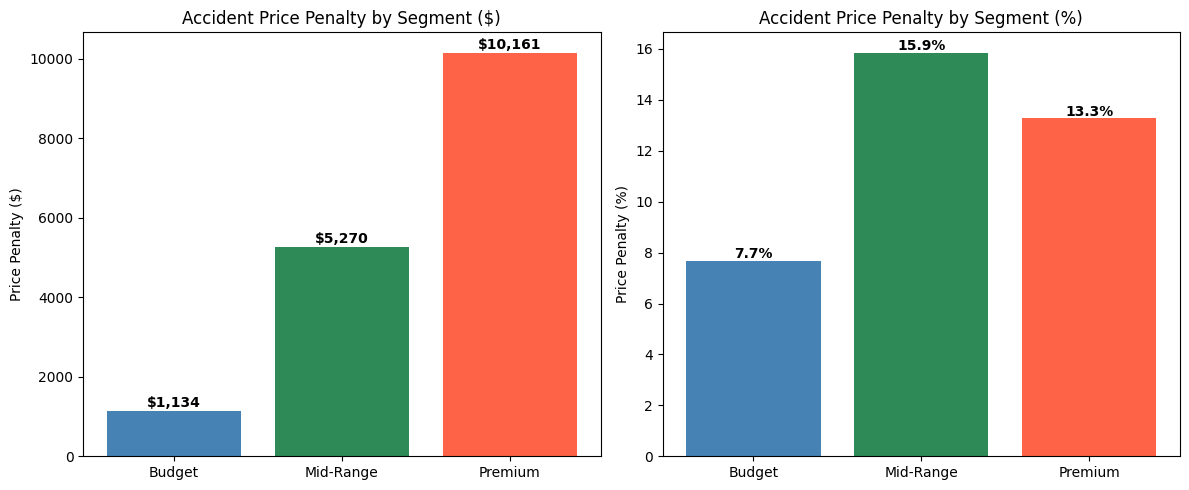

In [14]:
# Visualize accident penalty by segment
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

segs = list(accident_results.keys())
penalties_dollar = [accident_results[s]['Penalty $'] for s in segs]
penalties_pct = [accident_results[s]['Penalty %'] for s in segs]
colors = ['steelblue', 'seagreen', 'tomato']

axes[0].bar(segs, penalties_dollar, color=colors)
axes[0].set_title('Accident Price Penalty by Segment ($)')
axes[0].set_ylabel('Price Penalty ($)')
for i, v in enumerate(penalties_dollar):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontweight='bold')

axes[1].bar(segs, penalties_pct, color=colors)
axes[1].set_title('Accident Price Penalty by Segment (%)')
axes[1].set_ylabel('Price Penalty (%)')
for i, v in enumerate(penalties_pct):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('accident_penalty.png', dpi=150, bbox_inches='tight')
plt.show()

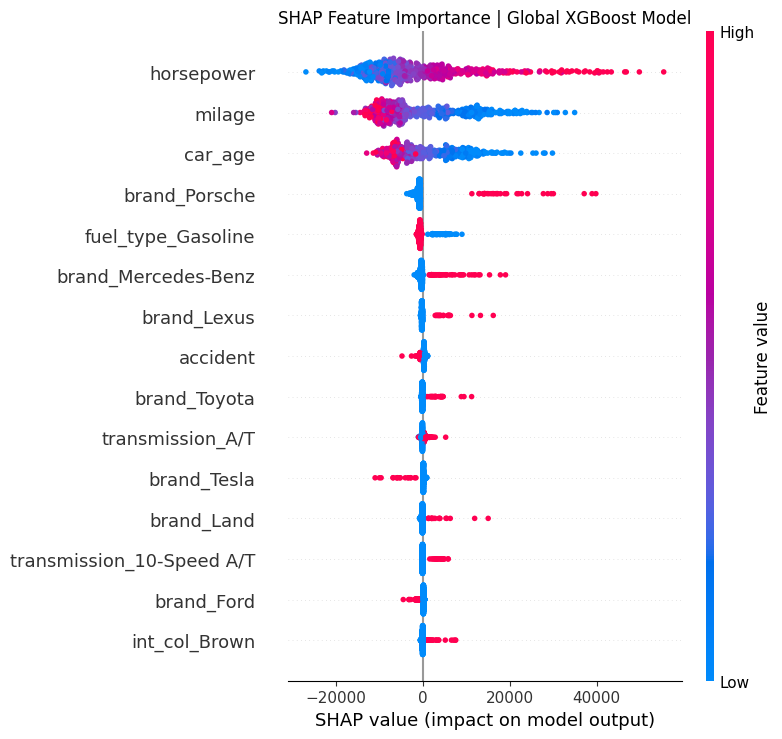

In [16]:
import shap

# SHAP on global XGBoost model
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('SHAP Feature Importance | Global XGBoost Model')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

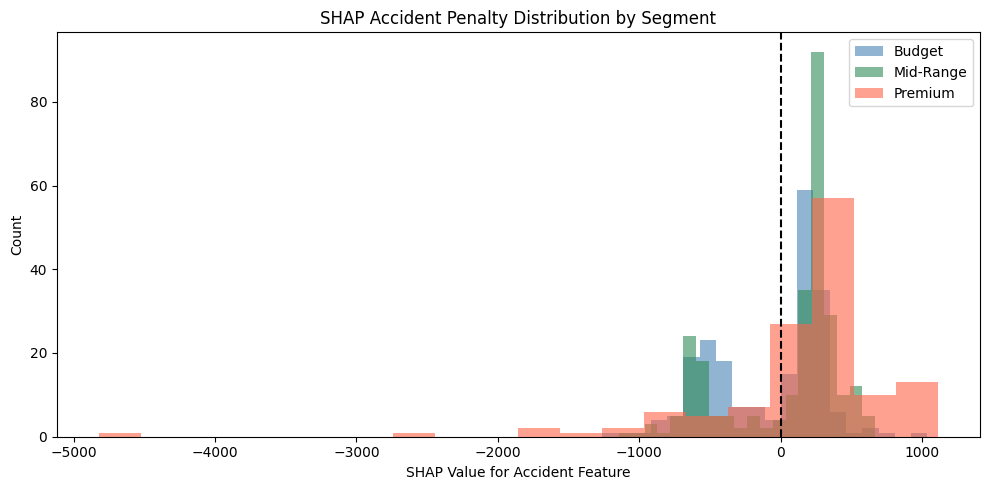

In [17]:
# SHAP accident affect per segment
segment_col = df_encoded.loc[X_test.index, 'segment']

plt.figure(figsize=(10, 5))
colors = {'Budget': 'steelblue', 'Mid-Range': 'seagreen', 'Premium': 'tomato'}
accident_idx = list(X_test.columns).index('accident')

for seg, color in colors.items():
    mask = segment_col == seg
    shap_accident = shap_values[mask, accident_idx]
    plt.hist(shap_accident, bins=20, alpha=0.6, color=color, label=seg)

plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('SHAP Value for Accident Feature')
plt.ylabel('Count')
plt.title('SHAP Accident Penalty Distribution by Segment')
plt.legend()
plt.tight_layout()
plt.savefig('shap_accident_segment.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Final results comparison table
results = {
    'Model': ['Linear Regression (Global)', 'Random Forest (Global)', 
              'XGBoost (Global)', 'XGBoost (Budget)', 
              'XGBoost (Mid-Range)', 'XGBoost (Premium)'],
    'RMSE': [f'${lr_rmse:,.0f}', f'${rf_rmse:,.0f}', f'${xgb_rmse:,.0f}',
             f'${seg_results["Budget"]["RMSE"]:,.0f}',
             f'${seg_results["Mid-Range"]["RMSE"]:,.0f}',
             f'${seg_results["Premium"]["RMSE"]:,.0f}'],
    'R²': [f'{lr_r2:.4f}', f'{rf_r2:.4f}', f'{xgb_r2:.4f}',
           f'{seg_results["Budget"]["R2"]:.4f}',
           f'{seg_results["Mid-Range"]["R2"]:.4f}',
           f'{seg_results["Premium"]["R2"]:.4f}']
}
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                     Model    RMSE     R²
Linear Regression (Global) $16,124 0.6954
    Random Forest (Global) $12,591 0.8142
          XGBoost (Global) $10,830 0.8626
          XGBoost (Budget)  $5,010 0.5316
       XGBoost (Mid-Range)  $6,840 0.6505
         XGBoost (Premium) $17,819 0.5971
